# Task 3: Quantum Tic-Tac-Toe
### MSE802 — Quantum Computing | Assessment 2

This notebook completes the Quantum Tic-Tac-Toe game provided in the course materials.
Two sections of code were incomplete:
- `make_move()` — the actual quantum gates were missing
- `countWinners()` — the 8 win condition triples were missing

In [7]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from ipywidgets import Button, Layout
import ipywidgets
import numpy as np
import math
from IPython.display import clear_output, display
from qiskit_aer import AerSimulator

## Board Class

The board holds a 9-qubit quantum circuit — one qubit per cell. Each qubit starts in superposition via an H gate, meaning no cell is owned by either player until measurement collapses the state.

The two completed sections are `make_move()` and `countWinners()`.

In [8]:
class Board:
    def __init__(self):
        self.qc = QuantumCircuit(9, 9)
        self.function = ''
        self.target = -1
        self.tab = []
        self.winsX = 0
        self.winsO = 0

        for idx in range(9):
            self.tab.append({'default': str(idx), 'player': ' '})
            self.qc.reset(idx)
            self.qc.h(idx)   # each cell starts in superposition
        self.qc.barrier()

    def make_move(self, cell):
        if self.function == 'Not':
            self.qc.x(int(cell))
            self.tab[int(cell)]['player'] += 'N - '

        elif self.function == 'O':
            self.qc.ry(-np.pi / 4, int(cell))
            self.tab[int(cell)]['player'] += 'O - '

        elif self.function == 'X':
            self.qc.ry(np.pi / 4, int(cell))
            self.tab[int(cell)]['player'] += 'X - '

        elif self.function == 'SWAP' and self.target != cell:
            self.qc.swap(int(self.target), int(cell))
            self.tab[int(cell)]['player'] += 'S - '
            self.tab[int(self.target)]['player'] += 'S - '

    def results(self):
        display(self.qc.draw('mpl'))
        self.qc = QuantumCircuit(9, 9)

    def display(self):
        display(self.qc.draw('mpl'))

    def measure(self):
        self.qc.barrier()
        for i in range(9):
            self.qc.measure(i, i)

        simulator = AerSimulator()
        job = simulator.run(self.qc, shots=1)
        counts = job.result().get_counts()
        output = list(counts.keys())[0]

        for i in range(9):
            if output[9 - 1 - i] == '0':
                self.tab[i]['player'] = 'X'
            else:
                self.tab[i]['player'] = 'O'

        self.winsX = self.countWinners('X')
        self.winsO = self.countWinners('O')

    def countWinners(self, player):
        winners = (
            (0, 1, 2),
            (3, 4, 5),
            (6, 7, 8),
            (0, 3, 6),
            (1, 4, 7),
            (2, 5, 8),
            (0, 4, 8),
            (2, 4, 6),
        )
        wins = 0
        for triple in winners:
            if all(self.tab[pos]['player'] == player for pos in triple):
                wins += 1
        return wins

    def new(self):
        self.tab.clear()
        for idx in range(9):
            self.tab.append({'default': str(idx), 'player': ''})
            self.qc.reset(idx)
            self.qc.h(idx)
        self.qc.barrier()

## Game Class

The Game class handles the interactive UI. The original code used `google.colab.widgets.Grid` which only works in Colab — replaced here with standard `ipywidgets.HBox` and `VBox` so it runs in VS Code.

In [9]:
class Game:
    FUNC_STYLES = {
        'Measure': ('#27ae60', '⚡ Measure'),
        'Not':     ('#8e44ad', '⊕ Not'),
        'O':       ('#2471a3', '◯  O Move'),
        'X':       ('#c0392b', '✕  X Move'),
        'SWAP':    ('#d68910', '⇄  SWAP'),
    }

    def __init__(self):
        self.selecting = False
        self.round = 0
        self.board = Board()

        self.status_html = ipywidgets.HTML(value=self._status_html('none'))

        self.boardbutton_list = []
        for i in range(9):
            btn = Button(description=str(i), layout=Layout(width='100px', height='90px'))
            btn.style.button_color = '#1a1a2e'
            btn.style.font_size = '22px'
            btn.style.text_color = 'white'
            btn.on_click(self.handle_game)
            self.boardbutton_list.append(btn)

        self.funcbutton_list = []
        for name, (color, label) in self.FUNC_STYLES.items():
            btn = Button(description=label, layout=Layout(width='140px', height='40px', margin='3px 0'))
            btn.style.button_color = color
            btn.style.text_color = 'white'
            btn.style.font_size = '13px'
            btn._func_name = name
            btn.on_click(self.handle_game)
            self.funcbutton_list.append(btn)

        self.score_html = ipywidgets.HTML(value=self._score_html())
        self._render()

    def _status_html(self, func):
        colors = {k: v[0] for k, v in self.FUNC_STYLES.items()}
        color = colors.get(func, '#555')
        label = self.FUNC_STYLES[func][1] if func in self.FUNC_STYLES else 'none'
        return f"""
        <div style='font-family:monospace; background:#0d0d1a; padding:8px 16px;
                    border-radius:8px; margin-bottom:6px; color:#ccc; font-size:13px;'>
            ⚛ <b style='color:#7ec8e3'>QUANTUM TIC-TAC-TOE</b>
            &nbsp;&nbsp;|&nbsp;&nbsp;
            Mode: <span style='background:{color};color:white;padding:2px 8px;
                               border-radius:4px;font-weight:bold'>{label}</span>
            &nbsp;&nbsp;|&nbsp;&nbsp; Round: <b style='color:#f0e130'>{self.round}</b>
        </div>"""

    def _score_html(self):
        return f"""
        <div style='font-family:monospace; background:#0d0d1a; padding:8px 16px;
                    border-radius:8px; margin-top:8px; text-align:center;'>
            <span style='color:#e74c3c; font-size:18px; font-weight:bold'>✕ X: {self.board.winsX}</span>
            &nbsp;&nbsp;&nbsp;
            <span style='color:#3498db; font-size:18px; font-weight:bold'>◯ O: {self.board.winsO}</span>
        </div>"""

    def _cell_color(self, idx):
        player = self.board.tab[idx]['player'].strip()
        if player == 'X':  return '#7b241c'
        if player == 'O':  return '#1a5276'
        x_count = player.count('X')
        o_count = player.count('O')
        if x_count > o_count:  return '#6e2f2f'
        if o_count > x_count:  return '#1c3d5a'
        if 'N' in player:      return '#4a235a'
        if 'S' in player:      return '#7d6608'
        return '#1a1a2e'

    def _cell_label(self, idx):
        player = self.board.tab[idx]['player'].strip()
        if player == 'X':  return '✕'
        if player == 'O':  return '◯'
        if not player:     return str(idx)
        sym = {'X': '→✕', 'O': '→◯', 'N': '⊕', 'S': '⇄'}
        parts = [sym[m] for m in ['X', 'O', 'N', 'S'] if m in player]
        return ' '.join(parts) if parts else str(idx)

    def _refresh_cells(self):
        for i, btn in enumerate(self.boardbutton_list):
            btn.description = self._cell_label(i)
            btn.style.button_color = self._cell_color(i)
            btn.style.text_color = 'white'

    def _render(self):
        board_rows = [
            ipywidgets.HBox(self.boardbutton_list[r*3:(r+1)*3], layout=Layout(gap='4px'))
            for r in range(3)
        ]
        board_box = ipywidgets.VBox(board_rows, layout=Layout(gap='4px'))
        controls = ipywidgets.VBox(
            self.funcbutton_list + [self.score_html],
            layout=Layout(margin='0 0 0 20px')
        )
        display(ipywidgets.VBox([self.status_html, ipywidgets.HBox([board_box, controls])]))

    def handle_game(self, b):
        func_name = getattr(b, '_func_name', None)

        if func_name == 'Measure':
            clear_output(wait=True)
            self.board.measure()
            self._refresh_cells()
            self.score_html.value = self._score_html()
            self.status_html.value = self._status_html('Measure')
            rep = Button(description='🔄 New Round', layout=Layout(width='140px', height='40px'))
            rep.style.button_color = '#27ae60'
            rep.style.text_color = 'white'
            rep._func_name = 'Replay'
            rep.on_click(self.handle_game)
            board_rows = [
                ipywidgets.HBox(self.boardbutton_list[r*3:(r+1)*3], layout=Layout(gap='4px'))
                for r in range(3)
            ]
            display(ipywidgets.VBox([
                self.status_html,
                ipywidgets.HBox([
                    ipywidgets.VBox(board_rows, layout=Layout(gap='4px')),
                    ipywidgets.VBox([rep, self.score_html], layout=Layout(margin='0 0 0 20px'))
                ])
            ]))
            display(self.board.qc.draw('mpl'))
            return

        if func_name == 'Replay':
            clear_output(wait=True)
            self.round = 0
            self.board = Board()
            for i, btn in enumerate(self.boardbutton_list):
                btn.description = str(i)
                btn.style.button_color = '#1a1a2e'
                btn.style.text_color = 'white'
            self.score_html.value = self._score_html()
            self.status_html.value = self._status_html('none')
            self._render()
            return

        if func_name in self.FUNC_STYLES:
            self.board.function = func_name
            self.selecting = (func_name == 'SWAP')
            self.status_html.value = self._status_html(func_name)
            return

        cell = self.boardbutton_list.index(b)

        if self.selecting:
            self.board.target = cell
            self.selecting = False
            self.board.make_move(cell)
        else:
            self.board.make_move(cell)

        self.round += 1
        self._refresh_cells()
        self.status_html.value = self._status_html(self.board.function)
        display(self.board.qc.draw('mpl'))

## Play the Game

Run the cell below to launch the game.

**How to play:**
- Click a function button (Not / O / X / SWAP) to select your move type
- Then click a cell number on the board to apply it
- For SWAP, click two cell numbers
- Click **Measure** to collapse the quantum state and count winners

In [10]:
game = Game()

---
## Programmatic Demo

This section demonstrates the game logic working without the interactive UI — useful for verifying the completed code.

Circuit before measurement:


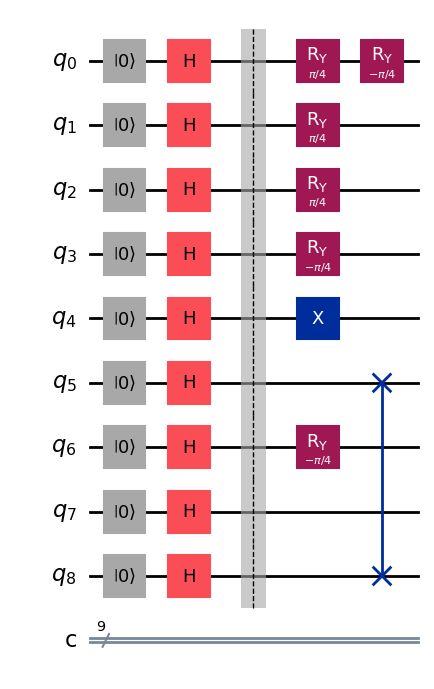

In [11]:
# simulate a sequence of moves and measure
demo = Board()

# player 1 tries to claim the top row with X moves
demo.function = 'X'
demo.make_move(0)
demo.make_move(1)
demo.make_move(2)

# player 2 tries the left column with O moves
demo.function = 'O'
demo.make_move(0)
demo.make_move(3)
demo.make_move(6)

# flip cell 4 with Not
demo.function = 'Not'
demo.make_move(4)

# swap cells 5 and 8
demo.function = 'SWAP'
demo.target = 5
demo.make_move(8)

print("Circuit before measurement:")
display(demo.qc.draw('mpl'))

In [12]:
# measure and check results
demo.measure()

print("Board after measurement:")
board_state = [demo.tab[i]['player'] for i in range(9)]
for row in range(3):
    print(' | '.join(board_state[row*3:(row+1)*3]))
    if row < 2:
        print('---------')

print(f"\nX wins: {demo.winsX}")
print(f"O wins: {demo.winsO}")

Board after measurement:
O | O | O
---------
X | X | O
---------
O | O | X

X wins: 0
O wins: 1


---
## Analysis

### Why This Game is Quantum

Unlike classical tic-tac-toe, this implementation allows each cell to exist in superposition until measurement. This means that the outcome of the game is not determined solely by player moves, but by probability amplitudes accumulated through quantum operations. This introduces non-deterministic gameplay, where identical move sequences can produce different results. This demonstrates a key advantage of quantum systems — the ability to represent and manipulate multiple possibilities simultaneously before collapsing to a single outcome.

### Measurement and Collapse

The measurement step is crucial, as it collapses the superposition of all qubits into a classical state. Before measurement, each qubit exists as a probability distribution of |0⟩ and |1⟩. Once measured, this probabilistic state becomes a definite value. This collapse explains why the same sequence of moves can result in different board outcomes across multiple runs.

### Circuit Perspective

The entire gameplay can be viewed as the gradual construction of a quantum circuit, where each player move appends quantum gates. Unlike static circuits, this dynamic construction means that the final state depends on the sequence and combination of operations applied over time. This highlights how quantum circuits can evolve based on user interaction.

### Limitations of the Model

One limitation of this implementation is that it relies on a simulator rather than real quantum hardware. As a result, it does not account for real-world noise, decoherence, and gate errors. Additionally, the use of a single-shot measurement simplifies the probabilistic nature of quantum systems, as running multiple shots would provide a more accurate probability distribution.

### Real-World Relevance

This type of quantum circuit modelling is relevant in real-world applications such as quantum optimisation, quantum simulations, and quantum machine learning, where systems evolve probabilistically before measurement. The game serves as an intuitive demonstration of how quantum states can be manipulated and observed.

---
## References
- Goff, A. (2006). Quantum tic-tac-toe: A teaching metaphor for superposition in quantum mechanics. *American Journal of Physics*, 74(11), 962–973.
- Qiskit Contributors. (2024). *Qiskit documentation*. IBM Quantum. https://docs.quantum.ibm.com
- Nielsen, M. A., & Chuang, I. L. (2010). *Quantum Computation and Quantum Information*. Cambridge University Press.

---
## Summary

What makes this game interesting is that it's not really tic-tac-toe anymore — it just looks like it. Under the hood, each cell is a qubit sitting in superposition, and every move you make is literally rotating or flipping a quantum state. You're not placing X's and O's, you're biasing probabilities.

The two pieces of code that were missing from the original lab made a big difference:

The `make_move()` function had the UI logic in place but nothing was actually being added to the quantum circuit. Once the gates were wired in — X for Not, RY rotations for the O and X moves, and SWAP between two qubits — the game actually does something quantum. Before that fix, clicking any button was effectively a no-op on the circuit.

The `countWinners()` function had an empty tuple, so no matter what happened after measurement, the score always showed 0–0. Adding the 8 win conditions (3 rows, 3 columns, 2 diagonals) made the scoring work, and it also revealed something you don't get in classical tic-tac-toe: both players can win at the same time. Since all 9 qubits collapse in a single measurement, the board can land in a state where X has a complete row and O has a complete column simultaneously.

Playing through a few rounds also showed that strategy matters in a non-obvious way. Applying the X move to the same cell repeatedly pushes that qubit closer and closer to |1⟩ — you're not guaranteed the outcome you want, but you're stacking the odds. The SWAP move is particularly powerful because it transfers whatever quantum state has built up in one cell to another position, which lets you move a well-contested qubit to a more useful spot right before measuring.

The original notebook was built for Google Colab, so the `google.colab.widgets.Grid` layout had to be replaced with `ipywidgets.HBox` and `VBox` to run locally in VS Code. The interactive button logic stayed the same — just the display layer changed.